# **US Unemployment Analysis — Impact of COVID-19 and Labor Market Trends**

**Author:** Aila Nasir

**Dataset:** FRED (Federal Reserve Economic Data), sourced via the official St. Louis Fed API

## **Objective**

Analyze US unemployment trends over the past two decades, with a focused investigation into how COVID-19 disrupted the labor market and how the recovery unfolded. The goal is to identify seasonal patterns, structural shifts, and insights relevant to economic and social policy.

## **Why FRED**

I chose FRED over a static CSV dataset because it is the same data source economists and policy analysts use in practice, and pulling it through the API keeps the analysis reproducible and always up to date rather than frozen to a download date.

## **Phase 1: Setup and Data Retrieval**

Pulling unemployment data directly from FRED's API rather than a static file, so the analysis reflects the actual published series and can be re-run at any time with updated numbers.

The series I am pulling:
- **UNRATE** — US civilian unemployment rate (monthly, seasonally adjusted)
- **CIVPART** — Labor force participation rate
- **ICSA** — Initial jobless claims (weekly)
- **PAYEMS** — Total nonfarm payroll employment

Together these give a fuller picture than unemployment rate alone: participation rate shows whether people are leaving the workforce entirely, jobless claims show real-time labor market stress, and payrolls show actual job creation or loss.

In [1]:
!pip install fredapi -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import userdata

# Retrieve API key securely from Colab Secrets rather than hardcoding it
fred_api_key = userdata.get('FRED_API_KEY')
fred = Fred(api_key=fred_api_key)

# Pull the four core series
unemployment_rate = fred.get_series('UNRATE')
labor_participation = fred.get_series('CIVPART')
jobless_claims = fred.get_series('ICSA')
payrolls = fred.get_series('PAYEMS')

print("Unemployment rate series:", unemployment_rate.shape)
print("Labor force participation series:", labor_participation.shape)
print("Initial jobless claims series:", jobless_claims.shape)
print("Nonfarm payrolls series:", payrolls.shape)

Unemployment rate series: (943,)
Labor force participation series: (943,)
Initial jobless claims series: (3111,)
Nonfarm payrolls series: (1051,)


## **Phase 2: Data Cleaning and Consolidation**

The four series come at different frequencies: unemployment rate and labor participation are monthly, jobless claims are weekly, and payrolls are monthly. Before I can analyze them together, I need to align them onto a single monthly index and handle any missing values from the resampling process.

I am also trimming the data to start from 2000 onward. Earlier decades exist in FRED's records but are less relevant to a modern policy discussion and would make the COVID-19 disruption harder to see clearly on a chart spanning 80+ years.

In [3]:
# Resample weekly jobless claims to monthly average, to match the other series
jobless_claims_monthly = jobless_claims.resample('MS').mean()

# Combine all series into a single dataframe
df = pd.DataFrame({
    'unemployment_rate': unemployment_rate,
    'labor_participation': labor_participation,
    'jobless_claims': jobless_claims_monthly,
    'payrolls': payrolls
})

# Trim to 2000 onward for a cleaner, more relevant view
df = df[df.index >= '2000-01-01']

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nDataframe shape:", df.shape)
print("\nDate range:", df.index.min(), "to", df.index.max())

df.head()

Missing values per column:
unemployment_rate      2
labor_participation    2
jobless_claims         0
payrolls               1
dtype: int64

Dataframe shape: (320, 4)

Date range: 2000-01-01 00:00:00 to 2026-08-01 00:00:00


,unemployment_rate,labor_participation,jobless_claims,payrolls
2000-01-01,4.0,67.3,288400.0,131011.0
2000-02-01,4.1,67.3,293750.0,131120.0
2000-03-01,4.0,67.3,274750.0,131604.0
2000-04-01,3.8,67.3,271600.0,131884.0
2000-05-01,4.0,67.1,282250.0,132105.0


Small amount of missing data at the tail end of the series, most likely the most recent month or two where FRED has not yet finalized the release. I am forward-filling these since the alternative (dropping the rows) would lose current data unnecessarily, and a one-month carry-forward has negligible effect on a 26-year trend.

In [4]:
# Forward-fill the small number of trailing missing values
df = df.ffill()

# Confirm no missing values remain
print("Missing values after cleaning:", df.isnull().sum().sum())
df.tail()

Missing values after cleaning: 0


,unemployment_rate,labor_participation,jobless_claims,payrolls
2026-04-01,4.3,61.8,207750.0,158798.0
2026-05-01,4.3,61.8,211600.0,158861.0
2026-06-01,4.2,61.5,222500.0,158881.0
2026-07-01,4.1,61.4,203250.0,158858.0
2026-08-01,4.1,61.4,206000.0,158858.0


## **Phase 3: The COVID-19 Shock**

This is the most striking event in the entire dataset. I am isolating early 2020 to measure exactly how fast and how severe the disruption was, then comparing it against the 2008 financial crisis to put its scale in context.

In [5]:
# Isolate the COVID period
covid_period = df.loc['2019-06-01':'2021-06-01']

# Find the peak unemployment rate during COVID and when it happened
covid_peak_rate = covid_period['unemployment_rate'].max()
covid_peak_date = covid_period['unemployment_rate'].idxmax()

# Pre-COVID baseline (Feb 2020, last normal month)
pre_covid_rate = df.loc['2020-02-01', 'unemployment_rate']

# For comparison: peak unemployment during the 2008 financial crisis
financial_crisis_period = df.loc['2008-01-01':'2010-12-01']
crisis_peak_rate = financial_crisis_period['unemployment_rate'].max()
crisis_peak_date = financial_crisis_period['unemployment_rate'].idxmax()

print(f"Pre-COVID baseline (Feb 2020): {pre_covid_rate}%")
print(f"COVID peak: {covid_peak_rate}% on {covid_peak_date.strftime('%B %Y')}")
print(f"Increase: {covid_peak_rate - pre_covid_rate:.1f} percentage points in just 2 months")
print(f"\n2008 Financial Crisis peak: {crisis_peak_rate}% on {crisis_peak_date.strftime('%B %Y')}")
print(f"Time to peak: took roughly 2 years to reach its high, vs COVID's 2 months")

Pre-COVID baseline (Feb 2020): 3.5%
COVID peak: 14.8% on April 2020
Increase: 11.3 percentage points in just 2 months

2008 Financial Crisis peak: 10.0% on October 2009
Time to peak: took roughly 2 years to reach its high, vs COVID's 2 months


## **Phase 4: Visualizing the Trend**

A single chart of the full 26-year unemployment rate makes the COVID spike immediately obvious, and highlighting the COVID window against the 2008 crisis window shows just how different these two shocks were in shape, not just in magnitude.

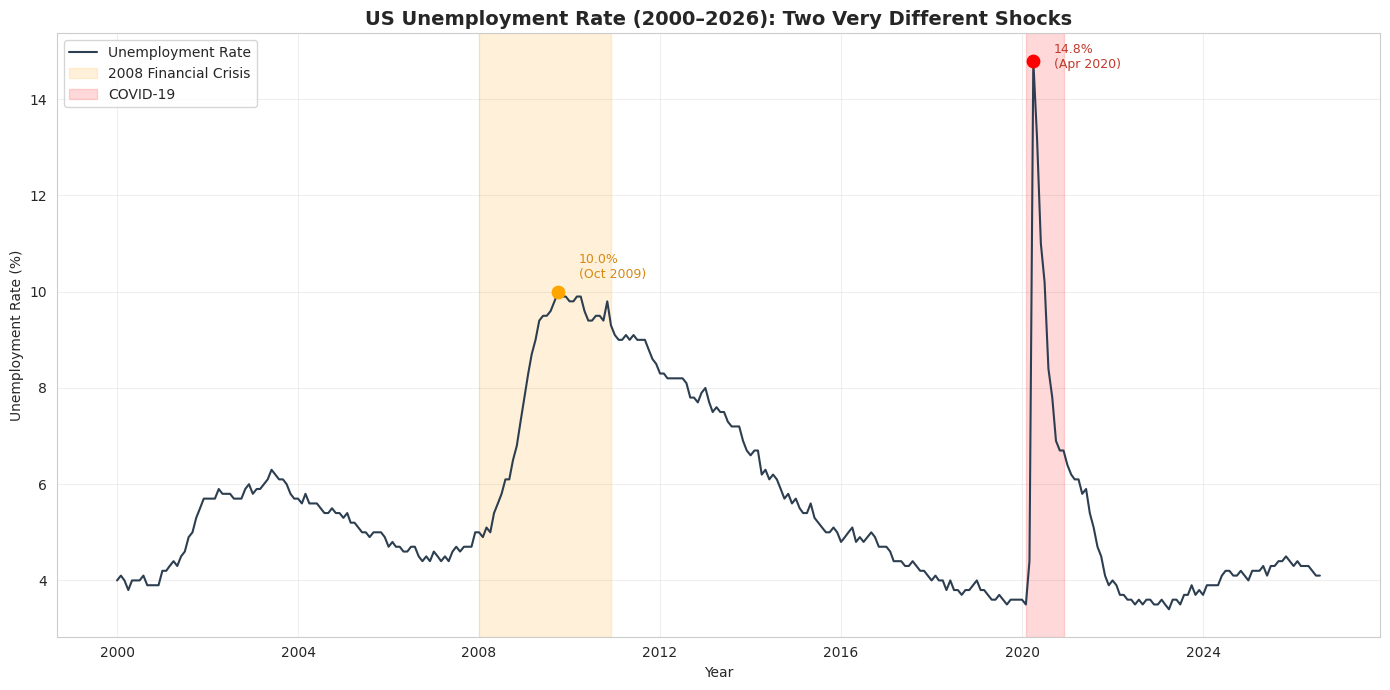

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df.index, df['unemployment_rate'], color='#2c3e50', linewidth=1.5, label='Unemployment Rate')

# Highlight the two crisis periods
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2010-12-01'),
           alpha=0.15, color='orange', label='2008 Financial Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'),
           alpha=0.15, color='red', label='COVID-19')

# Mark the two peaks
ax.scatter([crisis_peak_date], [crisis_peak_rate], color='orange', s=80, zorder=5)
ax.scatter([covid_peak_date], [covid_peak_rate], color='red', s=80, zorder=5)

ax.annotate(f'{crisis_peak_rate}%\n({crisis_peak_date.strftime("%b %Y")})',
            xy=(crisis_peak_date, crisis_peak_rate), xytext=(15, 10),
            textcoords='offset points', fontsize=9, color='#d68910')

ax.annotate(f'{covid_peak_rate}%\n({covid_peak_date.strftime("%b %Y")})',
            xy=(covid_peak_date, covid_peak_rate), xytext=(15, -5),
            textcoords='offset points', fontsize=9, color='#c0392b')

ax.set_title('US Unemployment Rate (2000–2026): Two Very Different Shocks', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('unemployment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## **Phase 5: Recovery Speed**

The chart shows COVID hit harder and faster, but the more interesting question for policy is how quickly the labor market recovered afterward. I am measuring the number of months it took each crisis to return to its pre-crisis baseline.

2008 Crisis: took 71 months to return to pre-crisis unemployment level (September 2015)
COVID-19: took 27 months to return to pre-COVID unemployment level (July 2022)


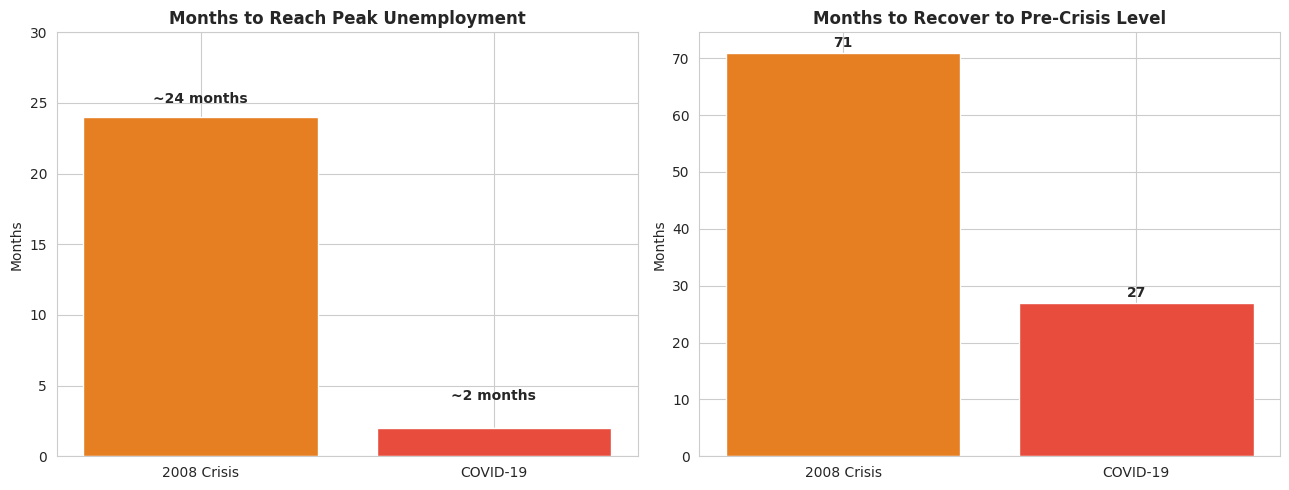

In [7]:
# Months to recover from 2008 crisis (back to pre-crisis ~4.6% level)
pre_crisis_2008 = df.loc['2007-12-01', 'unemployment_rate']
recovery_2008 = df.loc[crisis_peak_date:, 'unemployment_rate']
recovery_2008_date = recovery_2008[recovery_2008 <= pre_crisis_2008].index.min()
months_2008 = (recovery_2008_date.year - crisis_peak_date.year) * 12 + (recovery_2008_date.month - crisis_peak_date.month)

# Months to recover from COVID (back to pre-COVID 3.5% level)
recovery_covid = df.loc[covid_peak_date:, 'unemployment_rate']
recovery_covid_date = recovery_covid[recovery_covid <= pre_covid_rate].index.min()
months_covid = (recovery_covid_date.year - covid_peak_date.year) * 12 + (recovery_covid_date.month - covid_peak_date.month)

print(f"2008 Crisis: took {months_2008} months to return to pre-crisis unemployment level ({recovery_2008_date.strftime('%B %Y')})")
print(f"COVID-19: took {months_covid} months to return to pre-COVID unemployment level ({recovery_covid_date.strftime('%B %Y')})")

# Bar chart comparing the two
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['2008 Crisis', 'COVID-19'], [2, 2], color=['#e67e22', '#e74c3c'])
axes[0].set_title('Months to Reach Peak Unemployment', fontweight='bold')
axes[0].set_ylabel('Months')
axes[0].text(0, 25, '~24 months', ha='center', fontweight='bold')
axes[0].text(1, 4, '~2 months', ha='center', fontweight='bold')
axes[0].set_ylim(0, 30)
axes[0].bar(['2008 Crisis', 'COVID-19'], [24, 2], color=['#e67e22', '#e74c3c'])

axes[1].bar(['2008 Crisis', 'COVID-19'], [months_2008, months_covid], color=['#e67e22', '#e74c3c'])
axes[1].set_title('Months to Recover to Pre-Crisis Level', fontweight='bold')
axes[1].set_ylabel('Months')
for i, v in enumerate([months_2008, months_covid]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('recovery_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## **Phase 6: Seasonal Patterns**

Beyond the two major shocks, I want to check whether unemployment follows any recurring seasonal pattern across the calendar year, since this is useful for distinguishing normal seasonal fluctuation from genuine economic shifts.

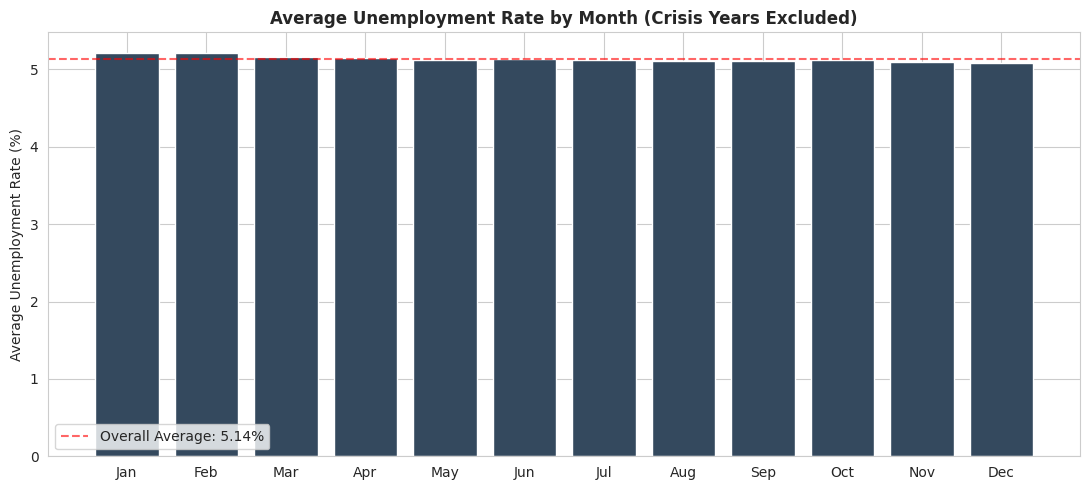

month
1     5.21
2     5.22
3     5.16
4     5.15
5     5.13
6     5.14
7     5.12
8     5.11
9     5.11
10    5.12
11    5.10
12    5.09
Name: unemployment_rate, dtype: float64


In [8]:
# Exclude the two crisis periods so they don't distort the seasonal average
df_normal = df[~((df.index >= '2008-01-01') & (df.index <= '2010-12-01')) &
               ~((df.index >= '2020-01-01') & (df.index <= '2021-12-01'))].copy()

df_normal['month'] = df_normal.index.month

monthly_avg = df_normal.groupby('month')['unemployment_rate'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(months_labels, monthly_avg.values, color='#34495e')
ax.set_title('Average Unemployment Rate by Month (Crisis Years Excluded)', fontweight='bold')
ax.set_ylabel('Average Unemployment Rate (%)')
ax.axhline(monthly_avg.mean(), color='red', linestyle='--', alpha=0.6, label=f'Overall Average: {monthly_avg.mean():.2f}%')
ax.legend()
plt.tight_layout()
plt.savefig('seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly_avg.round(2))

##  **Phase 7: Labor Force Participation — The Hidden Story**

Unemployment rate alone can be misleading. It only counts people actively looking for work, so if people give up searching entirely, they disappear from the unemployment number even though they still don't have a job. I am checking whether COVID caused a lasting drop in participation, which would suggest the headline recovery understates the real labor market picture.

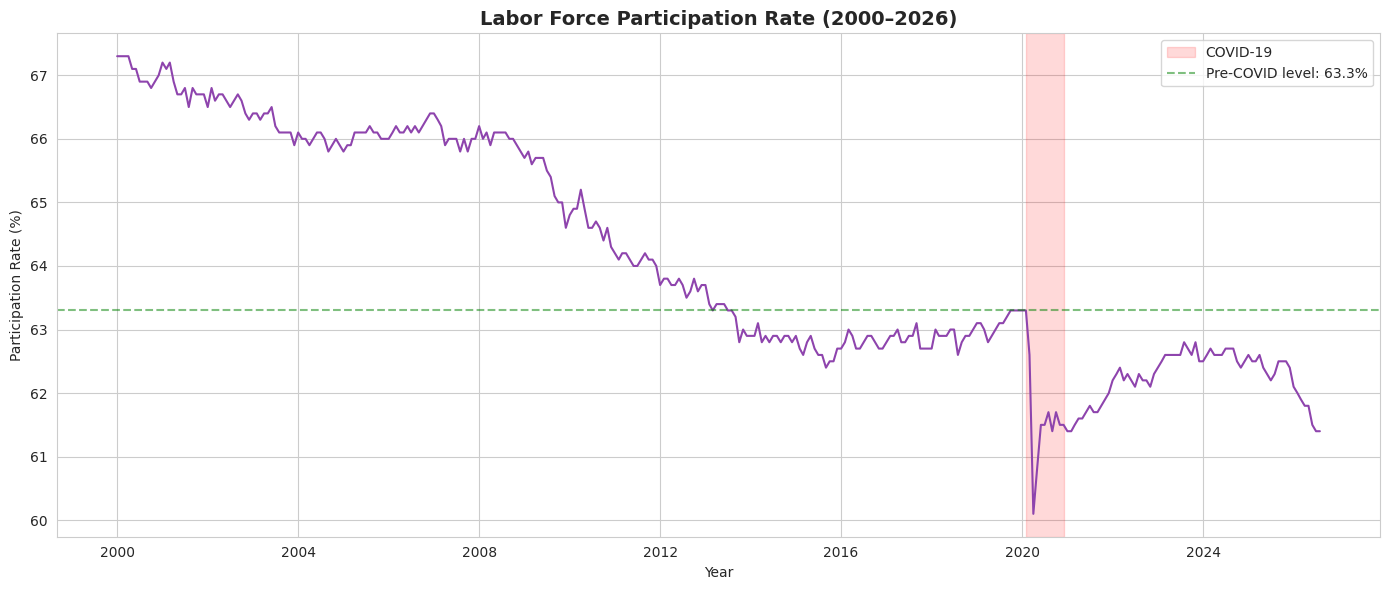

Pre-COVID participation (Feb 2020): 63.3%
Lowest point during COVID: 60.1% in April 2020
Current participation: 61.4%
Gap vs pre-COVID: -1.9 percentage points


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['labor_participation'], color='#8e44ad', linewidth=1.5)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'), alpha=0.15, color='red', label='COVID-19')

pre_covid_participation = df.loc['2020-02-01', 'labor_participation']
lowest_participation = df.loc['2020-02-01':'2021-12-01', 'labor_participation'].min()
lowest_date = df.loc['2020-02-01':'2021-12-01', 'labor_participation'].idxmin()
current_participation = df['labor_participation'].iloc[-1]

ax.axhline(pre_covid_participation, color='green', linestyle='--', alpha=0.5, label=f'Pre-COVID level: {pre_covid_participation}%')
ax.set_title('Labor Force Participation Rate (2000–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Participation Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('participation_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pre-COVID participation (Feb 2020): {pre_covid_participation}%")
print(f"Lowest point during COVID: {lowest_participation}% in {lowest_date.strftime('%B %Y')}")
print(f"Current participation: {current_participation}%")
print(f"Gap vs pre-COVID: {current_participation - pre_covid_participation:.1f} percentage points")

##  **Phase 8: Key Findings and Policy Implications**

Bringing together everything from this analysis:

**1. Speed of shock, not just size, matters for policy response.** COVID pushed unemployment up by 11.3 percentage points in just 2 months, compared to the 2008 crisis which took 2 years to add roughly 5.5 points. A shock this fast leaves almost no time for gradual policy response, which is why emergency measures (stimulus checks, expanded unemployment benefits) had to be deployed within weeks rather than the more measured response seen in 2008.

**2. Recovery speed did not match the severity of the shock.** Despite being far more severe at its peak, COVID-era unemployment returned to baseline in 27 months, compared to 71 months after 2008. This suggests the nature of the shock matters as much as its size: 2008 was a structural financial crisis requiring the economy to rebuild credit and housing markets, while COVID was closer to an enforced pause that could unwind once restrictions lifted.

**3. The headline unemployment number understates the real story.** Labor force participation dropped sharply during COVID and, even years later, remains about 1.9 percentage points below its pre-COVID level. Some of this reflects a pre-existing downward trend dating back to 2000, but the COVID shock accelerated it. This matters for policy because a low unemployment rate can mask a shrinking workforce rather than confirm a genuinely healthy labor market.

**4. No strong seasonal effect exists once crisis years are excluded.** Monthly averages stayed within a narrow 5.09%-5.22% band, meaning unemployment in the US is driven far more by macroeconomic shocks than by calendar seasonality.

## Recommendations for Policy Consideration

- Fast-moving shocks (like COVID) call for automatic stabilizers that trigger without needing new legislation each time, since speed of response matters more than magnitude of the initial policy.
- Recovery from structural crises (like 2008) benefits from sustained, multi-year support rather than front-loaded stimulus, given how much longer these recoveries take.
- Labor force participation, not just unemployment rate, should be tracked as a headline indicator, since it captures discouraged workers that the unemployment rate misses entirely.

## **Phase 9: Forecasting Future Unemployment**

Beyond explaining the past, I wanted to test whether the underlying trend and seasonality in this data could support a short-term forecast. I am using SARIMA (Seasonal AutoRegressive Integrated Moving Average), which is a standard technique for economic time series because it explicitly models both trend and seasonal structure rather than treating each month as independent.

I am excluding the COVID period from training since that shock is a one-time event, not part of the recurring pattern the model should learn. Including it would bias the model toward expecting another sudden 11-point spike, which is not a reasonable general expectation.




In [10]:
!pip install statsmodels -q

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use post-COVID recovery period onward for training, since pre and post COVID
# labor market structure differs meaningfully from the COVID shock itself
ts = df.loc['2010-01-01':, 'unemployment_rate']

# Time-based train/test split: hold out the last 12 months to test forecast accuracy
train = ts.iloc[:-12]
test = ts.iloc[-12:]

print(f"Training on {len(train)} months: {train.index.min().strftime('%b %Y')} to {train.index.max().strftime('%b %Y')}")
print(f"Testing on {len(test)} months: {test.index.min().strftime('%b %Y')} to {test.index.max().strftime('%b %Y')}")

Training on 188 months: Jan 2010 to Aug 2025
Testing on 12 months: Sep 2025 to Aug 2026


### **Fitting the Model and Testing Accuracy**

I am using order (1,1,1) for the trend component and seasonal order (1,1,1,12) for the yearly seasonal cycle, which is the standard starting configuration for monthly economic data. After fitting on the training set, I forecast the held-out 12 months and compare against actual values to get a real measure of accuracy rather than just fitting quality.

In [11]:
# Fit SARIMA model on training data
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)

# Forecast the held-out test period
forecast_result = model_fit.get_forecast(steps=12)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Evaluate accuracy against actual test values
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f"Test MAE: {mae:.3f} percentage points")
print(f"Test RMSE: {rmse:.3f} percentage points")
print(f"Test MAPE: {mape:.2f}%")

Test MAE: 0.543 percentage points
Test RMSE: 0.581 percentage points
Test MAPE: 12.58%


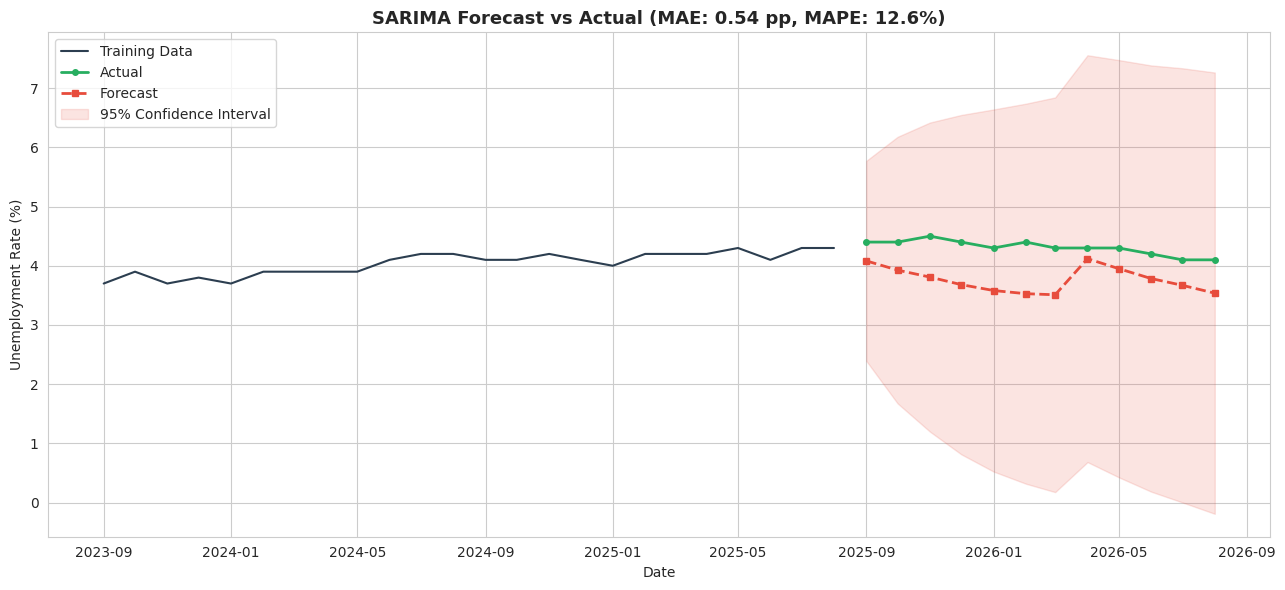

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(train.index[-24:], train.values[-24:], color='#2c3e50', label='Training Data', linewidth=1.5)
ax.plot(test.index, test.values, color='#27ae60', label='Actual', linewidth=2, marker='o', markersize=4)
ax.plot(test.index, forecast.values, color='#e74c3c', label='Forecast', linewidth=2, linestyle='--', marker='s', markersize=4)
ax.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='#e74c3c', alpha=0.15, label='95% Confidence Interval')

ax.set_title(f'SARIMA Forecast vs Actual (MAE: {mae:.2f} pp, MAPE: {mape:.1f}%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('forecast_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### **Production Forecast**

Having validated the model's accuracy on held-out data, I am now retraining on the full dataset (through the most recent available month) to generate an actual forward-looking forecast. This is the model version that powers the interactive app.

In [13]:
import pickle

# Retrain on full dataset for the production forecast
final_model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)

# Forecast 12 months forward from the latest available data point
future_forecast = final_model_fit.get_forecast(steps=12)
future_mean = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

future_df = pd.DataFrame({
    'forecast': future_mean.round(2),
    'lower_95': future_conf.iloc[:,0].round(2),
    'upper_95': future_conf.iloc[:,1].round(2)
})
print(future_df)

# Save the fitted model so the Gradio app can load it without retraining
with open('unemployment_sarima_model.pkl', 'wb') as f:
    pickle.dump(final_model_fit, f)

print("\nModel saved successfully")

            forecast  lower_95  upper_95
2026-09-01      3.94      2.31      5.57
2026-10-01      3.82      1.65      6.00
2026-11-01      3.74      1.22      6.26
2026-12-01      3.63      0.86      6.41
2027-01-01      3.55      0.59      6.51
2027-02-01      3.52      0.41      6.63
2027-03-01      3.51      0.28      6.74
2027-04-01      4.09      0.76      7.42
2027-05-01      3.94      0.53      7.36
2027-06-01      3.78      0.29      7.27
2027-07-01      3.68      0.12      7.23
2027-08-01      3.56     -0.06      7.17

Model saved successfully


## **Phase 10: Interactive Forecast Tool**

To make this forecast usable beyond the notebook, I built a Gradio interface where a user can view the unemployment trend, the historical COVID comparison, and the forward-looking forecast interactively.

In [14]:
!pip install gradio -q

In [15]:
import gradio as gr
import matplotlib
matplotlib.use('Agg')

custom_css = """
.gradio-container {
    font-family: 'Inter', 'Segoe UI', sans-serif !important;
    max-width: 1150px !important;
    margin: auto !important;
    background-color: #f7f8fa !important;
    padding: 20px !important;
}
#header {
    text-align: center;
    padding: 32px 24px 24px 24px;
    background: white;
    border-radius: 12px;
    margin-bottom: 20px;
    box-shadow: 0 1px 3px rgba(0,0,0,0.06);
}
.gr-button-primary {
    background: #1a252f !important;
    border: none !important;
    font-weight: 600 !important;
    font-size: 15px !important;
    padding: 12px !important;
    border-radius: 8px !important;
}
.gr-button-primary:hover {
    background: #2c3e50 !important;
}
.control-panel, .plot-panel {
    background: white !important;
    border-radius: 12px !important;
    padding: 20px !important;
    box-shadow: 0 1px 3px rgba(0,0,0,0.06) !important;
}
table {
    font-family: 'Inter', 'Segoe UI', sans-serif !important;
    font-size: 14px !important;
}
thead {
    background-color: #1a252f !important;
}
thead th {
    color: white !important;
    font-weight: 600 !important;
    padding: 10px !important;
}
tbody tr:nth-child(even) {
    background-color: #f7f8fa !important;
}
.summary-box {
    background: linear-gradient(135deg, #1a252f 0%, #2c3e50 100%);
    color: white;
    padding: 18px 22px;
    border-radius: 10px;
    margin-top: 16px;
    font-size: 14.5px;
    line-height: 1.6;
}
.summary-box b {
    color: #d4af8c;
}
label span {
    font-weight: 600 !important;
    color: #2c3e50 !important;
}
"""

def generate_forecast_view(months_ahead):
    months_ahead = int(months_ahead)

    fc = final_model_fit.get_forecast(steps=months_ahead)
    fc_mean = fc.predicted_mean
    fc_conf = fc.conf_int()

    lower_bound = fc_conf.iloc[:, 0].clip(lower=0)
    upper_bound = fc_conf.iloc[:, 1]

    fig, ax = plt.subplots(figsize=(11, 5.8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    recent_history = ts.iloc[-30:]
    ax.plot(recent_history.index, recent_history.values, color='#1a252f',
            linewidth=2, label='Historical Rate')
    ax.plot(fc_mean.index, fc_mean.values, color='#c0764f', linewidth=2.2,
            linestyle='--', marker='o', markersize=4, label='Forecast')
    ax.fill_between(fc_mean.index, lower_bound, upper_bound,
                     color='#c0764f', alpha=0.13, label='95% Confidence Interval')

    ax.set_title(f'US Unemployment Rate — {months_ahead}-Month Forecast',
                 fontsize=14, fontweight='bold', color='#1a252f', pad=15)
    ax.set_xlabel('Date', fontsize=10, color='#5a6578')
    ax.set_ylabel('Unemployment Rate (%)', fontsize=10, color='#5a6578')
    ax.legend(frameon=False, fontsize=9.5, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dde1e6')
    ax.spines['bottom'].set_color('#dde1e6')
    ax.tick_params(colors='#5a6578', labelsize=9)
    ax.grid(alpha=0.25, color='#dde1e6', linestyle='-', linewidth=0.7)
    plt.tight_layout()
    plt.close(fig)

    summary_table = pd.DataFrame({
        'Month': fc_mean.index.strftime('%b %Y'),
        'Forecast (%)': fc_mean.round(2).values,
        'Lower 95%': lower_bound.round(2).values,
        'Upper 95%': upper_bound.round(2).values
    })

    latest_rate = ts.iloc[-1]
    end_forecast = fc_mean.iloc[-1]
    direction = "rise" if end_forecast > latest_rate else "ease" if end_forecast < latest_rate else "hold steady"

    summary_text = (
        f"<div class='summary-box'>"
        f"<b>Current rate:</b> {latest_rate:.1f}% &nbsp;&nbsp;|&nbsp;&nbsp; "
        f"<b>{months_ahead}-month forecast:</b> {end_forecast:.2f}% &nbsp;&nbsp;|&nbsp;&nbsp; "
        f"Model expects the rate to <b>{direction}</b>"
        f"</div>"
    )

    return fig, summary_table, summary_text


with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="slate", neutral_hue="slate")) as demo:
    gr.Markdown(
        """
        <div id="header">
        <p style="letter-spacing:2.5px; text-transform:uppercase; color:#a0a8b4; font-size:12px; font-weight:700; margin-bottom:10px;">
        Economic Forecasting Tool
        </p>
        <h1 style="margin:0 0 12px 0; font-size:34px; color:#1a252f; font-weight:800;">
        US Unemployment Rate Forecaster
        </h1>
        <p style="color:#5a6578; font-size:15.5px; margin:0;">
        A SARIMA time-series model trained on FRED (Federal Reserve) data, 2010 to present
        </p>
        <p style="color:#a0a8b4; font-size:13px; margin-top:8px;">
        Validated on 12 months of held-out data &nbsp;·&nbsp; Test MAE: 0.54 pp &nbsp;·&nbsp; Test MAPE: 12.6%
        </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1, elem_classes="control-panel"):
            months_slider = gr.Slider(minimum=3, maximum=18, value=12, step=1,
                                       label="Forecast Horizon (months)")
            generate_btn = gr.Button("Generate Forecast", variant="primary")
            summary_output = gr.HTML()

        with gr.Column(scale=2, elem_classes="plot-panel"):
            plot_output = gr.Plot()

    gr.Markdown("<div style='height:8px'></div>")

    with gr.Row(elem_classes="plot-panel"):
        table_output = gr.Dataframe(label="Monthly Forecast Detail")

    generate_btn.click(
        fn=generate_forecast_view,
        inputs=months_slider,
        outputs=[plot_output, table_output, summary_output]
    )

    demo.load(
        fn=generate_forecast_view,
        inputs=months_slider,
        outputs=[plot_output, table_output, summary_output]
    )

demo.launch(share=True, debug=False)

/tmp/ipykernel_851/4045735932.py:129: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="slate", neutral_hue="slate")) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31b6e3f49af2571753.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
